<a href="https://colab.research.google.com/github/sv9-ru/model-for-predict/blob/main/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget "https://cmfdata.susu.ru/uploads_anal/5~1581073654-analysis/Analysis%20for%20Dataset%201.zip"

!unzip -j "Analysis for Dataset 1.zip"

--2026-04-04 09:16:47--  https://cmfdata.susu.ru/uploads_anal/5~1581073654-analysis/Analysis%20for%20Dataset%201.zip
Resolving cmfdata.susu.ru (cmfdata.susu.ru)... 37.75.250.13
Connecting to cmfdata.susu.ru (cmfdata.susu.ru)|37.75.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139279 (136K) [application/zip]
Saving to: ‘Analysis for Dataset 1.zip’

Analysis for Datase 100%[===================>] 136.01K   291KB/s    in 0.5s    

2026-04-04 09:16:49 (291 KB/s) - ‘Analysis for Dataset 1.zip’ saved [139279/139279]

Archive:  Analysis for Dataset 1.zip
  inflating: example.py              
  inflating: dataset1_full.xlsx      
  inflating: dataset2.xlsx           
  inflating: dataset3.xlsx           
  inflating: dataset4.xlsx           


In [11]:
# @title
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn import preprocessing, metrics, svm
import joblib
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error,
                           explained_variance_score)

# Загрузка модели
model = joblib.load('/content/SVR_MFR_dataset1 (1).pkl')

# Загрузка данных
dataset1 = pd.read_excel('/content/dataset1_full.xlsx')

# Column numbers
MFR_obs = 5
DD = 7
MFR_err = 8
DD_err = 10

# Start row number
row_start = 3

# Extracting research data
X_test_df1 = dataset1.iloc[row_start:, [MFR_obs, DD]].values.astype(float)
y_test_df1_MFR = dataset1.iloc[row_start:, [MFR_err]].values.astype(float)

# Нормализация данных
X_scaler_ds1 = preprocessing.StandardScaler().fit(X_test_df1)
X_test_df1_scaled = X_scaler_ds1.transform(X_test_df1)

y_scaler_ds1 = preprocessing.StandardScaler().fit(y_test_df1_MFR)
y_test_df1_scaled = y_scaler_ds1.transform(y_test_df1_MFR)

# Предсказания
predictions_scaled = model.predict(X_test_df1_scaled)

# Обратное преобразование предсказаний в исходный масштаб
predictions = y_scaler_ds1.inverse_transform(predictions_scaled.reshape(-1, 1))

# Исходные значения
y_true = y_test_df1_MFR

# Расчет метрик
mse = mean_squared_error(y_true, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, predictions)
mape = mean_absolute_percentage_error(y_true, predictions)
r2 = r2_score(y_true, predictions)
evs = explained_variance_score(y_true, predictions)

# Дополнительные метрики
n = len(y_true)
p = X_test_df1.shape[1]  # количество признаков
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Вывод метрик
print("=" * 50)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ SVR")
print("=" * 50)
print(f"MSE  (Среднеквадратичная ошибка):     {mse:.6f}")
print(f"RMSE (Корень из MSE):                {rmse:.6f}")
print(f"MAE  (Средняя абсолютная ошибка):    {mae:.6f}")
print(f"MAPE (Средняя % ошибка):             {mape:.4%}")
print(f"R²   (Коэффициент детерминации):     {r2:.6f}")
print(f"Adj R² (Скорректированный R²):       {adj_r2:.6f}")
print(f"EVS  (Доля объясненной дисперсии):   {evs:.6f}")
print("=" * 50)

# Дополнительная статистика
print("\nДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 50)
residuals = y_true.flatten() - predictions.flatten()
print(f"Среднее остатков:                    {np.mean(residuals):.6f}")
print(f"Станд. отклонение остатков:          {np.std(residuals):.6f}")
print(f"Макс. положительная ошибка:          {np.max(residuals):.6f}")
print(f"Мин. отрицательная ошибка:           {np.min(residuals):.6f}")
print(f"95-й перцентиль |ошибки|:            {np.percentile(np.abs(residuals), 95):.6f}")

# Сравнение первых 10 предсказаний с реальными значениями
print("\nСРАВНЕНИЕ ПЕРВЫХ 10 ПРЕДСКАЗАНИЙ:")
print("-" * 50)
print(f"{'№':<4} {'Реальное':<12} {'Предсказанное':<14} {'Ошибка':<12}")
print("-" * 50)
for i in range(min(10, len(y_true))):
    print(f"{i+1:<4} {y_true[i][0]:<12.4f} {predictions[i][0]:<14.4f} {residuals[i]:<12.4f}")
print("=" * 50)


МЕТРИКИ КАЧЕСТВА МОДЕЛИ SVR
MSE  (Среднеквадратичная ошибка):     1.848238
RMSE (Корень из MSE):                1.359499
MAE  (Средняя абсолютная ошибка):    0.747026
MAPE (Средняя % ошибка):             33.9526%
R²   (Коэффициент детерминации):     0.986161
Adj R² (Скорректированный R²):       0.985742
EVS  (Доля объясненной дисперсии):   0.986282

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
--------------------------------------------------
Среднее остатков:                    -0.126943
Станд. отклонение остатков:          1.353559
Макс. положительная ошибка:          5.049989
Мин. отрицательная ошибка:           -6.621327
95-й перцентиль |ошибки|:            3.084499

СРАВНЕНИЕ ПЕРВЫХ 10 ПРЕДСКАЗАНИЙ:
--------------------------------------------------
№    Реальное     Предсказанное  Ошибка      
--------------------------------------------------


IndexError: invalid index to scalar variable.

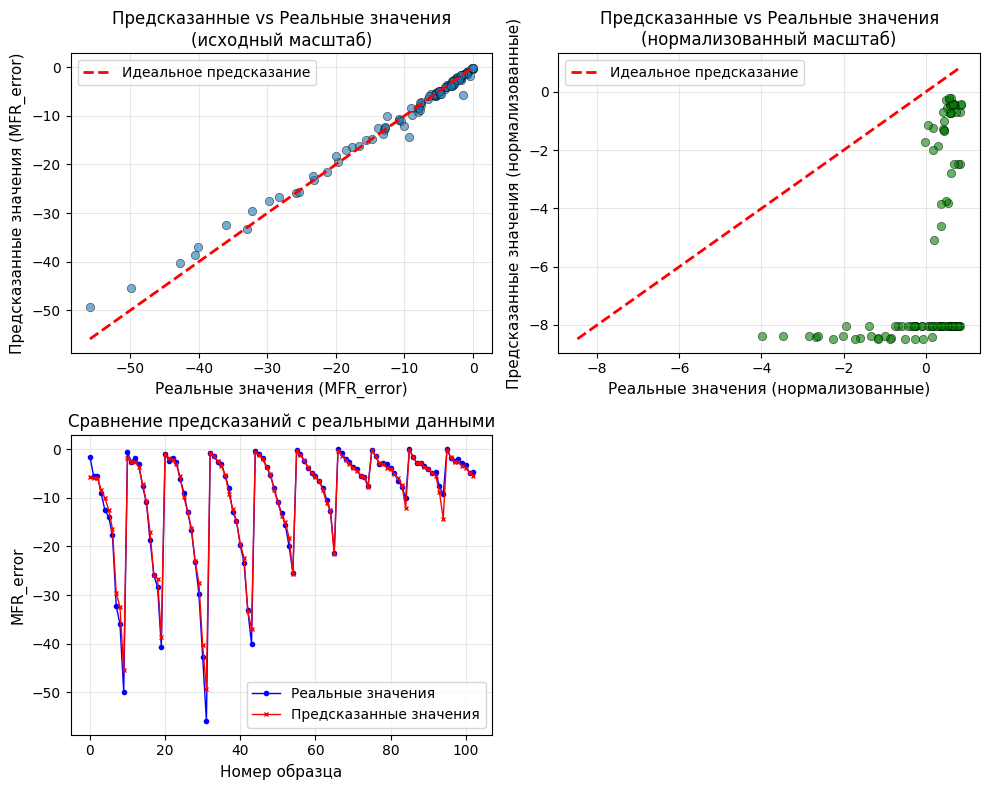


✅ Все графики успешно построены!


In [12]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# 1. ГРАФИК: Предсказанные vs Реальные значения (в исходном масштабе)
# ==================================================
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.scatter(y_true, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
# Линия идеального предсказания
min_val = min(y_true.min(), predictions.min())
max_val = max(y_true.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения (MFR_error)', fontsize=11)
plt.ylabel('Предсказанные значения (MFR_error)', fontsize=11)
plt.title('Предсказанные vs Реальные значения\n(исходный масштаб)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# ==================================================
# 2. ГРАФИК: Предсказанные vs Реальные значения (в нормализованном масштабе)
# ==================================================
plt.subplot(2, 2, 2)
plt.scatter(y_test_df1_scaled, predictions_scaled, alpha=0.6, edgecolors='k', linewidth=0.5, color='green')
min_val_scaled = min(y_test_df1_scaled.min(), predictions_scaled.min())
max_val_scaled = max(y_test_df1_scaled.max(), predictions_scaled.max())
plt.plot([min_val_scaled, max_val_scaled], [min_val_scaled, max_val_scaled], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения (нормализованные)', fontsize=11)
plt.ylabel('Предсказанные значения (нормализованные)', fontsize=11)
plt.title('Предсказанные vs Реальные значения\n(нормализованный масштаб)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# ==================================================
# 3. ГРАФИК: Сравнение предсказаний с реальными данными (линейный график)
# ==================================================
plt.subplot(2, 2, 3)
indices = np.arange(len(y_true))
plt.plot(indices, y_true, 'b-', label='Реальные значения', marker='o', markersize=3, linewidth=1)
plt.plot(indices, predictions, 'r-', label='Предсказанные значения', marker='x', markersize=3, linewidth=1)
plt.xlabel('Номер образца', fontsize=11)
plt.ylabel('MFR_error', fontsize=11)
plt.title('Сравнение предсказаний с реальными данными', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\n✅ Все графики успешно построены!")

In [33]:
%%writefile /content/config.txt
# КОНФИГУРАЦИОННЫЙ ФАЙЛ ДЛЯ МОДЕЛИ ПРЕДСКАЗАНИЯ
# ==================================================

# Пути к файлам
model_path = /content/SVR_MFR_dataset1 (1).pkl          # Путь к модели
dataset_path = /content/dataset1_full.xlsx              # Путь к датасету

# Настройки данных
MFR_obs_col = 5        # Номер колонки с MFR наблюдениями
DD_col = 7             # Номер колонки с DD
MFR_err_col = 8        # Номер колонки с MFR ошибкой
DD_err_col = 10        # Номер колонки с DD ошибкой
row_start = 3          # Строка начала данных (пропуск заголовков)

# Режимы предсказания
prediction_mode = dataset    # dataset - из датасета, manual - ручной ввод
target_metric = MFR          # MFR или DD (что предсказывать)

# Временные настройки
prediction_interval = 0      # 0 - мгновенно, 1 - 1 секунда

# Обработка данных
normalize_data = True        # True - нормализовать, False - не нормализовать

# Отображение
show_progress = True         # Показывать прогресс
max_display_samples = 10     # Максимум образцов для отображения

# Сохранение результатов
save_predictions = True                     # Сохранять предсказания в CSV
predictions_output = /content/predictions_results.csv   # Путь для сохранения
save_plots = True                           # Сохранять графики
plots_dir = /content/plots/                 # Директория для графиков

# ==================================================
# ИНСТРУКЦИЯ:
# ==================================================
# • Для мгновенных предсказаний: prediction_interval = 0
# • Для задержки 1 сек: prediction_interval = 1
# • Для теста на датасете: prediction_mode = dataset
# • Для ручного ввода: prediction_mode = manual
# • Для MFR: target_metric = MFR
# • Для DD: target_metric = DD
# ==================================================

Overwriting /content/config.txt


In [31]:
# @title
%%writefile /content/my_script.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Скрипт для предсказания с использованием загруженной модели
Поддерживает предсказания из датасета или ручной ввод
"""

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn import preprocessing
import joblib
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error,
                           explained_variance_score)
import warnings
import os
import sys
warnings.filterwarnings('ignore')

# ==================================================
# ФУНКЦИЯ ЗАГРУЗКИ КОНФИГУРАЦИИ
# ==================================================
def load_config(config_path='/content/config.txt'):
    """Загрузка конфигурации из текстового файла"""
    config = {}

    if not os.path.exists(config_path):
        print(f" Файл конфигурации не найден: {config_path}")
        print("Использую настройки по умолчанию")
        return get_default_config()

    with open(config_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Пропускаем комментарии и пустые строки
            if line and not line.startswith('#'):
                if '=' in line:
                    key, value = line.split('=', 1)
                    key = key.strip()
                    value = value.strip()

                    # Преобразование типов
                    if value.lower() in ['true', 'false']:
                        config[key] = value.lower() == 'true'
                    elif value.isdigit():
                        config[key] = int(value)
                    elif value.replace('.', '').replace('-', '').isdigit():
                        config[key] = float(value)
                    else:
                        config[key] = value

    print(f" Конфигурация загружена из {config_path}")
    return config

def get_default_config():
    """Настройки по умолчанию"""
    return {
        'model_path': '/content/SVR_MFR_dataset1 (1).pkl',
        'dataset_path': '/content/dataset1_full.xlsx',
        'MFR_obs_col': 5,
        'DD_col': 7,
        'MFR_err_col': 8,
        'DD_err_col': 10,
        'row_start': 3,
        'prediction_mode': 'dataset',
        'target_metric': 'MFR',
        'prediction_interval': 0,
        'normalize_data': True,
        'show_progress': True,
        'max_display_samples': 10,
        'save_predictions': True,
        'predictions_output': '/content/predictions_results.csv',
        'save_plots': True,  # Новая настройка: сохранять графики
        'plots_dir': '/content/plots/'  # Директория для сохранения графиков
    }

# ==================================================
# ФУНКЦИЯ РУЧНОГО ВВОДА ДАННЫХ
# ==================================================
def manual_prediction_loop(model, X_scaler, y_scaler, config, feature_names=['MFR_obs', 'DD']):
    """Цикл ручного ввода данных для предсказания"""
    print("\n" + "="*60)
    print("РЕЖИМ РУЧНОГО ВВОДА ДАННЫХ")
    print("="*60)
    print("Введите значения признаков для предсказания")
    print("Для выхода введите 'q' или 'quit'")
    print("-"*60)

    predictions_history = []
    input_history = []

    while True:
        try:
            print(f"\n Введите {feature_names[0]} и {feature_names[1]}:")
            user_input = input("→ ").strip()

            if user_input.lower() in ['q', 'quit', 'exit']:
                print("\n Выход из режима ручного ввода")
                break

            # Парсинг ввода
            values = user_input.split()
            if len(values) < 2:
                print(" Ошибка: введите два числа через пробел")
                continue

            val1 = float(values[0])
            val2 = float(values[1])

            # Создание массива признаков
            X_input = np.array([[val1, val2]])

            # Нормализация (если включена)
            if config['normalize_data'] and X_scaler is not None:
                X_input_scaled = X_scaler.transform(X_input)
            else:
                X_input_scaled = X_input

            # Предсказание
            start_time = time.perf_counter()
            pred_scaled = model.predict(X_input_scaled)
            pred_time = time.perf_counter() - start_time

            # Обратное преобразование
            if config['normalize_data'] and y_scaler is not None:
                prediction = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]
            else:
                prediction = pred_scaled[0]

            # Сохранение истории
            input_history.append([val1, val2])
            predictions_history.append(prediction)

            # Вывод результата
            print(f"\n РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ:")
            print(f"   • {feature_names[0]}: {val1}")
            print(f"   • {feature_names[1]}: {val2}")
            print(f"   • Предсказанный {config['target_metric']}: {prediction:.6f}")
            print(f"   • Время предсказания: {pred_time*1000:.2f} мс")

            # Задержка (если задана)
            if config['prediction_interval'] > 0:
                time.sleep(config['prediction_interval'])

        except ValueError:
            print(" Ошибка: введите корректные числа")
        except Exception as e:
            print(f" Ошибка при предсказании: {e}")

    return np.array(input_history) if input_history else np.array([]), np.array(predictions_history) if predictions_history else np.array([])

# ==================================================
# ОСНОВНАЯ ФУНКЦИЯ
# ==================================================
def main():
    print("="*60)
    print("СИСТЕМА ПРЕДСКАЗАНИЯ НА ОСНОВЕ ML МОДЕЛИ")
    print("="*60)

    # Загрузка конфигурации
    config = load_config('/content/config.txt')

    # Вывод конфигурации
    print("\n ТЕКУЩАЯ КОНФИГУРАЦИЯ:")
    print("-"*40)
    for key, value in config.items():
        print(f"   {key}: {value}")
    print("-"*40)

    # Создание директории для графиков
    if config.get('save_plots', True):
        os.makedirs(config.get('plots_dir', '/content/plots/'), exist_ok=True)
        print(f" Графики будут сохранены в: {config.get('plots_dir', '/content/plots/')}")

    # Проверка режима предсказания
    if config['prediction_interval'] == 0:
        print(" Режим предсказания: МГНОВЕННЫЙ (без задержки)")
    else:
        print(f"⏱  Режим предсказания: ЗАДЕРЖКА {config['prediction_interval']} сек")

    # ==================================================
    # ЗАГРУЗКА МОДЕЛИ
    # ==================================================
    print("\nЗагрузка модели...")
    try:
        if not os.path.exists(config['model_path']):
            raise FileNotFoundError(f"Файл модели не найден: {config['model_path']}")
        model = joblib.load(config['model_path'])
        print(f" Модель загружена: {type(model).__name__}")
    except Exception as e:
        print(f" Ошибка загрузки модели: {e}")
        return

    # ==================================================
    # ПОДГОТОВКА НОРМАЛИЗАТОРОВ (если нужны)
    # ==================================================
    X_scaler = None
    y_scaler = None

    if config['normalize_data'] and config['prediction_mode'] == 'manual':
        print("\n  Для ручного режима с нормализацией нужны эталонные данные")
        print("   Будут использованы данные из датасета для обучения нормализаторов")

        if os.path.exists(config['dataset_path']):
            try:
                dataset = pd.read_excel(config['dataset_path'])
                X_temp = dataset.iloc[config['row_start']:, [config['MFR_obs_col'], config['DD_col']]].values.astype(float)
                y_temp = dataset.iloc[config['row_start']:, [config['MFR_err_col']]].values.astype(float)

                X_scaler = preprocessing.StandardScaler().fit(X_temp)
                y_scaler = preprocessing.StandardScaler().fit(y_temp)
                print(" Нормализаторы обучены на датасете")
            except Exception as e:
                print(f" Ошибка при обучении нормализаторов: {e}")
                config['normalize_data'] = False
        else:
            print(" Датасет не найден, нормализация отключена")
            config['normalize_data'] = False

    # ==================================================
    # РЕЖИМ ПРЕДСКАЗАНИЯ: ИЗ ДАТАСЕТА
    # ==================================================
    if config['prediction_mode'] == 'dataset':
        print("\n РЕЖИМ ПРЕДСКАЗАНИЯ: ИЗ ДАТАСЕТА")

        # Загрузка датасета
        print("\n Загрузка датасета...")
        try:
            if not os.path.exists(config['dataset_path']):
                raise FileNotFoundError(f"Файл датасета не найден: {config['dataset_path']}")
            dataset = pd.read_excel(config['dataset_path'])
            print(f" Датасет загружен: {dataset.shape[0]} строк")
        except Exception as e:
            print(f" Ошибка загрузки датасета: {e}")
            return

        # Подготовка данных
        print("\n Подготовка данных...")
        X_data = dataset.iloc[config['row_start']:, [config['MFR_obs_col'], config['DD_col']]].values.astype(float)

        if config['target_metric'] == 'MFR':
            y_data = dataset.iloc[config['row_start']:, [config['MFR_err_col']]].values.astype(float)
        else:  # DD
            y_data = dataset.iloc[config['row_start']:, [config['DD_err_col']]].values.astype(float)

        print(f"Подготовлено {len(X_data)} образцов")

        # Нормализация
        if config['normalize_data']:
            print(" Применяется нормализация...")
            X_scaler = preprocessing.StandardScaler().fit(X_data)
            X_data_scaled = X_scaler.transform(X_data)

            y_scaler = preprocessing.StandardScaler().fit(y_data)
            y_data_scaled = y_scaler.transform(y_data)
            print(" Данные нормализованы")
            use_scaled = True
        else:
            X_data_scaled = X_data
            y_data_scaled = y_data
            use_scaled = False

        # Пошаговое предсказание
        print(f"\n{'='*60}")
        print("НАЧАЛО ПРЕДСКАЗАНИЙ")
        print(f"{'='*60}")

        predictions = []
        prediction_times = []
        y_true_list = []

        for i in range(len(X_data)):
            start_time = time.perf_counter()

            current_sample = X_data_scaled[i:i+1] if use_scaled else X_data[i:i+1]
            pred_scaled = model.predict(current_sample)

            if use_scaled and y_scaler is not None:
                pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]
            else:
                pred = pred_scaled[0]

            pred_time = time.perf_counter() - start_time

            predictions.append(pred)
            prediction_times.append(pred_time)
            y_true_list.append(y_data[i][0])

            if config['show_progress'] and (i < config['max_display_samples'] or i % 50 == 0 or i == len(X_data)-1):
                print(f"Образец {i+1:3d}/{len(X_data)} | "
                      f"Истинное: {y_data[i][0]:8.4f} | "
                      f"Предсказание: {pred:8.4f} | "
                      f"Время: {pred_time*1000:6.2f} мс")

            if config['prediction_interval'] > 0 and i < len(X_data) - 1:
                time.sleep(config['prediction_interval'])

        # Преобразование в numpy массивы
        predictions = np.array(predictions)
        y_true = np.array(y_true_list)
        prediction_times = np.array(prediction_times)

        # Расчет метрик
        print(f"\n{'='*60}")
        print("РАСЧЕТ МЕТРИК КАЧЕСТВА")
        print(f"{'='*60}")

        mse = mean_squared_error(y_true, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, predictions)
        mape = mean_absolute_percentage_error(y_true, predictions)
        r2 = r2_score(y_true, predictions)
        evs = explained_variance_score(y_true, predictions)

        n = len(y_true)
        p = X_data.shape[1]
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p else r2

        # Таблица метрик
        metrics_data = {
            'Метрика': ['MSE', 'RMSE', 'MAE', 'MAPE', 'R²', 'Adj R²', 'EVS'],
            'Значение': [
                f"{mse:.6f}", f"{rmse:.6f}", f"{mae:.6f}",
                f"{mape:.4%}", f"{r2:.6f}", f"{adj_r2:.6f}", f"{evs:.6f}"
            ]
        }
        metrics_df = pd.DataFrame(metrics_data)
        print("\n", metrics_df.to_string(index=False))

        # Временные метрики
        print(f"\n  ВРЕМЕННЫЕ МЕТРИКИ:")
        print(f"   • Среднее время: {np.mean(prediction_times)*1000:.2f} мс")
        print(f"   • Стд. отклонение: {np.std(prediction_times)*1000:.2f} мс")
        print(f"   • Мин. время: {np.min(prediction_times)*1000:.2f} мс")
        print(f"   • Макс. время: {np.max(prediction_times)*1000:.2f} мс")
        print(f"   • Общее время: {np.sum(prediction_times):.2f} сек")

        # Сохранение результатов
        if config['save_predictions']:
            results_df = pd.DataFrame({
                'Sample': range(1, len(predictions)+1),
                'True_Value': y_true,
                'Prediction': predictions,
                'Absolute_Error': np.abs(y_true - predictions),
                'Prediction_Time_ms': prediction_times * 1000
            })
            results_df.to_csv(config['predictions_output'], index=False)
            print(f"\n Результаты сохранены в: {config['predictions_output']}")

            # Также сохраняем метрики в отдельный файл
            metrics_df.to_csv('/content/metrics_summary.csv', index=False)
            print(f" Метрики сохранены в: /content/metrics_summary.csv")

        # Построение и сохранение графиков
        residuals = y_true - predictions
        plot_results(y_true, predictions, prediction_times, residuals, config)

    # ==================================================
    # РЕЖИМ ПРЕДСКАЗАНИЯ: РУЧНОЙ ВВОД
    # ==================================================
    else:
        print("\n РЕЖИМ ПРЕДСКАЗАНИЯ: РУЧНОЙ ВВОД")
        input_data, predictions_history = manual_prediction_loop(model, X_scaler, y_scaler, config)

        if len(predictions_history) > 0:
            # Сохранение истории ручных предсказаний
            if config['save_predictions']:
                results_df = pd.DataFrame({
                    'MFR_obs': input_data[:, 0],
                    'DD': input_data[:, 1],
                    f'Predicted_{config["target_metric"]}': predictions_history
                })
                results_df.to_csv(config['predictions_output'], index=False)
                print(f"\n История предсказаний сохранена в: {config['predictions_output']}")
        else:
            print("\n Нет данных для сохранения")

    print("\n" + "="*60)
    print(" РАБОТА ЗАВЕРШЕНА")
    print("="*60)

# ==================================================
# ФУНКЦИЯ ПОСТРОЕНИЯ И СОХРАНЕНИЯ ГРАФИКОВ
# ==================================================
def plot_results(y_true, predictions, prediction_times, residuals, config):
    """Построение и сохранение графиков результатов"""
    print("\n Построение и сохранение графиков...")

    # Создаем директорию для графиков, если её нет
    plots_dir = config.get('plots_dir', '/content/plots/')
    os.makedirs(plots_dir, exist_ok=True)

    # Список для хранения имен сохраненных файлов
    saved_files = []

    # 1. ГРАФИК: Предсказанные vs Реальные
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
    min_val = min(y_true.min(), predictions.min())
    max_val = max(y_true.max(), predictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание')
    plt.xlabel('Реальные значения', fontsize=12)
    plt.ylabel('Предсказанные значения', fontsize=12)
    plt.title(f'Предсказанные vs Реальные значения\n{config["target_metric"]}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    filepath1 = os.path.join(plots_dir, '1_predicted_vs_actual.png')
    plt.savefig(filepath1, dpi=300, bbox_inches='tight')
    saved_files.append(filepath1)
    plt.show()

    # 2. ГРАФИК: Временной ряд
    plt.figure(figsize=(12, 6))
    indices = np.arange(len(y_true))
    plt.plot(indices, y_true, 'b-', label='Реальные значения', marker='o', markersize=3, linewidth=1, alpha=0.7)
    plt.plot(indices, predictions, 'r-', label='Предсказанные значения', marker='x', markersize=3, linewidth=1, alpha=0.7)
    plt.xlabel('Номер образца', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title('Сравнение предсказаний с реальными данными', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    filepath2 = os.path.join(plots_dir, '2_time_series.png')
    plt.savefig(filepath2, dpi=300, bbox_inches='tight')
    saved_files.append(filepath2)
    plt.show()

    # 5. ГРАФИК: Время предсказания по образцам
    plt.figure(figsize=(12, 6))
    plt.plot(indices, [t*1000 for t in prediction_times], 'g-', marker='s', markersize=3, linewidth=1, alpha=0.7)
    plt.xlabel('Номер образца', fontsize=12)
    plt.ylabel('Время предсказания (мс)', fontsize=12)
    plt.title('Время предсказания для каждого образца', fontsize=14)
    plt.grid(True, alpha=0.3)
    filepath5 = os.path.join(plots_dir, '5_prediction_time_series.png')
    plt.savefig(filepath5, dpi=300, bbox_inches='tight')
    saved_files.append(filepath5)
    plt.show()

    # Вывод информации о сохраненных файлах
    print("\n" + "="*60)
    print(" СОХРАНЕННЫЕ ГРАФИКИ:")
    print("="*60)
    for i, filepath in enumerate(saved_files, 1):
        print(f"{i}. {filepath}")
    print(f"\n Все графики сохранены в директории: {plots_dir}")
    print("="*60)

# ==================================================
# ЗАПУСК СКРИПТА
# ==================================================
if __name__ == "__main__":
    main()

Overwriting /content/my_script.py


In [34]:
# Ячейка 3: Запуск программы
!python /content/my_script.py

СИСТЕМА ПРЕДСКАЗАНИЯ НА ОСНОВЕ ML МОДЕЛИ
 Конфигурация загружена из /content/config.txt

 ТЕКУЩАЯ КОНФИГУРАЦИЯ:
----------------------------------------
   model_path: /content/SVR_MFR_dataset1 (1).pkl          # Путь к модели
   dataset_path: /content/dataset1_full.xlsx              # Путь к датасету
   MFR_obs_col: 5        # Номер колонки с MFR наблюдениями
   DD_col: 7             # Номер колонки с DD
   MFR_err_col: 8        # Номер колонки с MFR ошибкой
   DD_err_col: 10        # Номер колонки с DD ошибкой
   row_start: 3          # Строка начала данных (пропуск заголовков)
   prediction_mode: dataset    # dataset - из датасета, manual - ручной ввод
   target_metric: MFR          # MFR или DD (что предсказывать)
   prediction_interval: 0      # 0 - мгновенно, 1 - 1 секунда
   normalize_data: True        # True - нормализовать, False - не нормализовать
   show_progress: True         # Показывать прогресс
   max_display_samples: 10     # Максимум образцов для отображения
   save_pr